<a href="https://colab.research.google.com/github/arunpr2313/24ADI006_24BAD012/blob/main/Ex_4_Food_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

# **Part A : Dataset Preparation**

In [1]:
print("Arun PR  24BAD012")
import kagglehub
import tensorflow as tf
import os

# 1. Download dataset from Kaggle
path = kagglehub.dataset_download("harishkumardatalab/food-image-classification-dataset")
print("Dataset downloaded to:", path)

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def find_class_folder_root(base_path):
    """
    Automatically locates the directory that directly contains one
    sub-folder per class (each sub-folder holding image files), so no
    manual path inspection is needed regardless of how the Kaggle zip
    was structured.
    """
    for root, dirs, files_list in os.walk(base_path):
        subdirs = [d for d in dirs if not d.startswith(".")]
        if len(subdirs) < 2:
            continue
        # check that most sub-folders directly hold image files
        image_subdirs = 0
        for d in subdirs:
            sub_path = os.path.join(root, d)
            if any(f.lower().endswith(IMAGE_EXTS) for f in os.listdir(sub_path)):
                image_subdirs += 1
        if image_subdirs >= max(2, len(subdirs) // 2):
            return root
    return base_path

data_dir = find_class_folder_root(path)
class_folders = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
print("Using data_dir:", data_dir)
print("Detected classes:", len(class_folders))
print(class_folders)

Arun PR  24BAD012


100%|██████████| 1.68G/1.68G [01:21<00:00, 22.3MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/harishkumardatalab/food-image-classification-dataset/versions/1
Using data_dir: /root/.cache/kagglehub/datasets/harishkumardatalab/food-image-classification-dataset/versions/1/Food Classification dataset
Detected classes: 34
['kaathi_rolls', 'Baked Potato', 'momos', 'sushi', 'kadai_paneer', 'dhokla', 'Taco', 'kulfi', 'chai', 'Donut', 'masala_dosa', 'chicken_curry', 'samosa', 'chapati', 'omelette', 'apple_pie', 'Sandwich', 'ice_cream', 'burger', 'Crispy Chicken', 'butter_naan', 'fried_rice', 'jalebi', 'Hot Dog', 'Taquito', 'chole_bhature', 'pizza', 'cheesecake', 'idli', 'Fries', 'pakode', 'pav_bhaji', 'dal_makhani', 'paani_puri']


In [ ]:
# 2. Load and preprocess images
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.3, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.3, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

print("Class names:", train_ds.class_names)
class_names = train_ds.class_names   # saved now — lost after .prefetch() below

# 3. Split validation set further into val/test
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 23873 files belonging to 34 classes.
Using 16712 files for training.
Found 23873 files belonging to 34 classes.
Using 7161 files for validation.
Class names: ['Baked Potato', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Sandwich', 'Taco', 'Taquito', 'apple_pie', 'burger', 'butter_naan', 'chai', 'chapati', 'cheesecake', 'chicken_curry', 'chole_bhature', 'dal_makhani', 'dhokla', 'fried_rice', 'ice_cream', 'idli', 'jalebi', 'kaathi_rolls', 'kadai_paneer', 'kulfi', 'masala_dosa', 'momos', 'omelette', 'paani_puri', 'pakode', 'pav_bhaji', 'pizza', 'samosa', 'sushi']


# **Part B: Implementing Transfer Learning**

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pre-trained ResNet-50 without the top classification layer
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze the feature extraction layers
base_model.trainable = False

# Replace the final classification layer for our dataset's classes
num_classes = len(class_names)   # derived from the food dataset's folders (saved earlier)
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

# Compile the model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 34)        │     69,666 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,657,378 (90.25 MB)

 Trainable params: 69,666 (272.13 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## **Part C: Model Training and Performance Evaluation**

In [ ]:
EPOCHS = 10
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

Epoch 1/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 132s 205ms/step - accuracy: 0.6479 - loss: 1.2419 - val_accuracy: 0.7864 - val_loss: 0.7276
Epoch 2/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 97s 186ms/step - accuracy: 0.8005 - loss: 0.6612 - val_accuracy: 0.7987 - val_loss: 0.7125
Epoch 3/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 79s 151ms/step - accuracy: 0.8314 - loss: 0.5484 - val_accuracy: 0.8194 - val_loss: 0.6357
Epoch 4/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 81s 149ms/step - accuracy: 0.8479 - loss: 0.4796 - val_accuracy: 0.8188 - val_loss: 0.6428
Epoch 5/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 83s 150ms/step - accuracy: 0.8618 - loss: 0.4327 - val_accuracy: 0.8183 - val_loss: 0.6405
Epoch 6/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 96s 183ms/step - accuracy: 0.8696 - loss: 0.4014 - val_accuracy: 0.8242 - val_loss: 0.6442
Epoch 7/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 78s 149ms/step - accuracy: 0.8778 - loss: 0.3800 - val_accuracy: 0.8183 - val_loss: 0.6574
Epoch 8/10
523/523 ━━━━━━━━━━━━━━━━━━━━ 79s 150ms/step - accuracy: 0.8753 - loss: 

In [ ]:
# Record per-epoch training/validation accuracy and loss
for i in range(EPOCHS):
    print(
        f"Epoch {i+1} - "
        f"train_acc: {history.history['accuracy'][i]:.4f}, "
        f"val_acc: {history.history['val_accuracy'][i]:.4f}, "
        f"train_loss: {history.history['loss'][i]:.4f}, "
        f"val_loss: {history.history['val_loss'][i]:.4f}"
    )

Epoch 1 - train_acc: 0.6479, val_acc: 0.7864, train_loss: 1.2419, val_loss: 0.7276
Epoch 2 - train_acc: 0.8005, val_acc: 0.7987, train_loss: 0.6612, val_loss: 0.7125
Epoch 3 - train_acc: 0.8314, val_acc: 0.8194, train_loss: 0.5484, val_loss: 0.6357
Epoch 4 - train_acc: 0.8479, val_acc: 0.8188, train_loss: 0.4796, val_loss: 0.6428
Epoch 5 - train_acc: 0.8618, val_acc: 0.8183, train_loss: 0.4327, val_loss: 0.6405
Epoch 6 - train_acc: 0.8696, val_acc: 0.8242, train_loss: 0.4014, val_loss: 0.6442
Epoch 7 - train_acc: 0.8778, val_acc: 0.8183, train_loss: 0.3800, val_loss: 0.6574
Epoch 8 - train_acc: 0.8753, val_acc: 0.8113, train_loss: 0.3819, val_loss: 0.6946
Epoch 9 - train_acc: 0.8838, val_acc: 0.8267, train_loss: 0.3544, val_loss: 0.6596
Epoch 10 - train_acc: 0.8866, val_acc: 0.8283, train_loss: 0.3473, val_loss: 0.6570


In [ ]:
# Record test accuracy/loss
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 121ms/step - accuracy: 0.8290 - loss: 0.6401
Test accuracy: 0.8289620280265808
Test loss: 0.6401383280754089


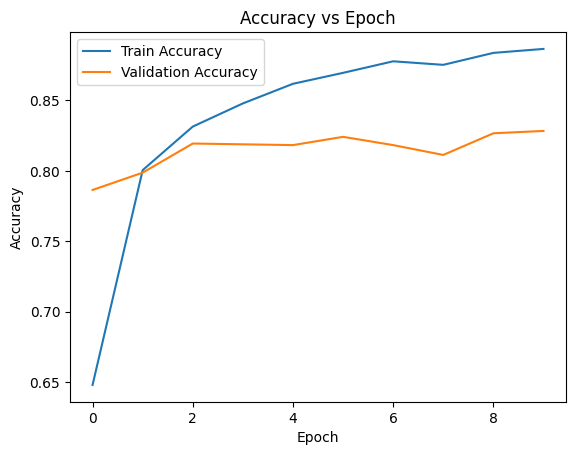

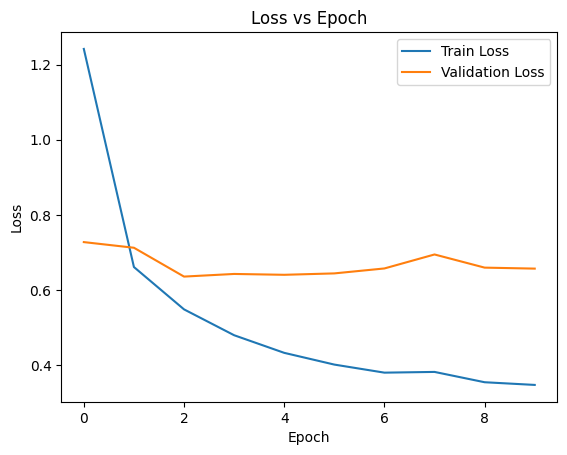

In [ ]:
import matplotlib.pyplot as plt

# Accuracy vs Epoch
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy vs Epoch")
plt.show()

# Loss vs Epoch
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss vs Epoch")
plt.show()

## **Part D: Using Hugging Face Pre-Trained Models**

In [ ]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch
from PIL import Image

# Load a pre-trained vision model from Hugging Face (ViT), trained on
# the full 1000-class ImageNet set — NOT fine-tuned on our food classes
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
hf_model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

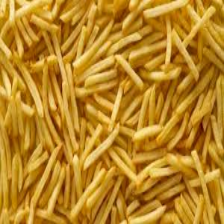

True label: Fries
ResNet50 (fine-tuned) prediction: Fries
Hugging Face ViT prediction: cheeseburger
--------------------------------------------------


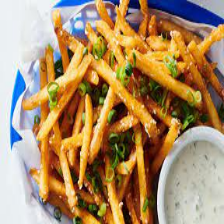

True label: Fries
ResNet50 (fine-tuned) prediction: Fries
Hugging Face ViT prediction: cheeseburger
--------------------------------------------------


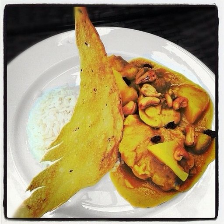

True label: chicken_curry
ResNet50 (fine-tuned) prediction: omelette
Hugging Face ViT prediction: plate
--------------------------------------------------


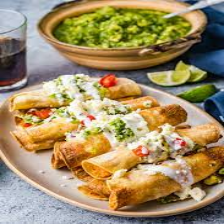

True label: Taquito
ResNet50 (fine-tuned) prediction: Taquito
Hugging Face ViT prediction: guacamole
--------------------------------------------------


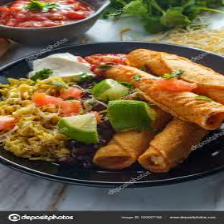

True label: Taquito
ResNet50 (fine-tuned) prediction: Crispy Chicken
Hugging Face ViT prediction: plate
--------------------------------------------------


In [ ]:
# Perform image classification on several sample images from the test
# set, and compare against the fine-tuned ResNet50 transfer learning
# model's predictions on the same images
sample_ds = test_ds.unbatch().take(5)

for img_tensor, label in sample_ds:
    img_array = img_tensor.numpy().astype("uint8")
    pil_img = Image.fromarray(img_array)
    true_class = class_names[label.numpy()]

    # --- Fine-tuned ResNet50 transfer learning model ---
    input_arr = tf.expand_dims(img_tensor, axis=0)
    my_pred = model.predict(input_arr, verbose=0)
    my_class = class_names[tf.argmax(my_pred[0]).numpy()]

    # --- Hugging Face ViT (general ImageNet) model ---
    hf_inputs = processor(images=pil_img, return_tensors="pt")
    with torch.no_grad():
        hf_logits = hf_model(**hf_inputs).logits
    hf_class = hf_model.config.id2label[hf_logits.argmax(-1).item()]

    display(pil_img)
    print("True label:", true_class)
    print("ResNet50 (fine-tuned) prediction:", my_class)
    print("Hugging Face ViT prediction:", hf_class)
    print("-" * 50)

**Observations:**

- The fine-tuned ResNet50 model always predicts one of the food classes present in our training dataset, since its output layer was replaced and trained specifically on those classes.
- The Hugging Face ViT model was trained on the full 1000-class ImageNet set and was never fine-tuned on this food dataset. As a result, its predictions are often more general (e.g. a broad ImageNet label that isn't one of our specific food categories) or occasionally mismatched, even when the image is confidently classified by our fine-tuned model.
- This comparison illustrates the core value of transfer learning: starting from strong general-purpose features (ImageNet pre-training) and fine-tuning the final layers on task-specific data produces much more accurate, domain-relevant predictions than a general-purpose pre-trained model used as-is.
- Where the two models agree, it is typically on food classes that are visually distinctive and also well represented among ImageNet's own labels.